In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

url = "https://data.cityofnewyork.us/resource/h9gi-nx95.json"
params = {"$limit": 50000}

resp = requests.get(url, params=params)
df = pd.DataFrame(resp.json())  # cleaner than json.loads(resp.text)

In [ ]:
url = "https://data.cityofnewyork.us/resource/h9gi-nx95.json"
params = {"$limit": 50000}

response = requests.get(url, params=params)
df = pd.DataFrame(response.json())

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 50000, Columns: 29


,crash_date,crash_time,on_street_name,off_street_name,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,...,latitude,longitude,location,contributing_factor_vehicle_3,vehicle_type_code_3,cross_street_name,contributing_factor_vehicle_4,vehicle_type_code_4,contributing_factor_vehicle_5,vehicle_type_code_5
0,2021-09-11T00:00:00.000,2:39,WHITESTONE EXPRESSWAY,20 AVENUE,2,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-03-26T00:00:00.000,11:45,QUEENSBORO BRIDGE UPPER,NaN,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-11-01T00:00:00.000,1:29,OCEAN PARKWAY,AVENUE K,1,0,0,0,0,0,...,40.62179,-73.970024,"{'latitude': '40.62179', 'longitude': '-73.970...",Unspecified,Sedan,NaN,NaN,NaN,NaN,NaN
3,2022-06-29T00:00:00.000,6:55,THROGS NECK BRIDGE,NaN,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-09-21T00:00:00.000,13:21,BROOKLYN BRIDGE,NaN,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
if "location" in df.columns:
    df = df.drop(columns=["location"])

#remove duplicates
rows_before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {rows_before - len(df)}")

Duplicates removed: 0


In [ ]:
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_") #remove extra spaces and standardize
print(df.columns.tolist())

['crash_date', 'crash_time', 'on_street_name', 'off_street_name', 'number_of_persons_injured', 'number_of_persons_killed', 'number_of_pedestrians_injured', 'number_of_pedestrians_killed', 'number_of_cyclist_injured', 'number_of_cyclist_killed', 'number_of_motorist_injured', 'number_of_motorist_killed', 'contributing_factor_vehicle_1', 'contributing_factor_vehicle_2', 'collision_id', 'vehicle_type_code1', 'vehicle_type_code2', 'borough', 'zip_code', 'latitude', 'longitude', 'contributing_factor_vehicle_3', 'vehicle_type_code_3', 'cross_street_name', 'contributing_factor_vehicle_4', 'vehicle_type_code_4', 'contributing_factor_vehicle_5', 'vehicle_type_code_5']


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
crash_date                           0
crash_time                           0
on_street_name                   13573
off_street_name                  26912
number_of_persons_injured            0
number_of_persons_killed             0
number_of_pedestrians_injured        0
number_of_pedestrians_killed         0
number_of_cyclist_injured            0
number_of_cyclist_killed             0
number_of_motorist_injured           0
number_of_motorist_killed            0
contributing_factor_vehicle_1      250
contributing_factor_vehicle_2    11182
collision_id                         0
vehicle_type_code1                 601
vehicle_type_code2               16467
borough                          17291
zip_code                         17297
latitude                          3910
longitude                         3910
contributing_factor_vehicle_3    44670
vehicle_type_code_3              45056
cross_street_name                36428
contributing_factor_vehicle_4    4855

In [ ]:
rows_before = len(df)

# Drop rows missing critical columns
df = df.dropna(subset=["crash_date", "borough", "latitude", "longitude"])

print(f"Rows removed: {rows_before - len(df)}")
print(f"Rows remaining: {len(df)}")

Rows removed: 18095
Rows remaining: 31905


In [ ]:
df["crash_date"] = pd.to_datetime(df["crash_date"])
df["number_of_persons_injured"] = pd.to_numeric(df["number_of_persons_injured"], errors="coerce")
df["number_of_persons_killed"] = pd.to_numeric(df["number_of_persons_killed"], errors="coerce")
print("Data types converted.")
print(df.dtypes)

Data types converted.
crash_date                       datetime64[ns]
crash_time                               object
on_street_name                           object
off_street_name                          object
number_of_persons_injured                 int64
number_of_persons_killed                  int64
number_of_pedestrians_injured            object
number_of_pedestrians_killed             object
number_of_cyclist_injured                object
number_of_cyclist_killed                 object
number_of_motorist_injured               object
number_of_motorist_killed                object
contributing_factor_vehicle_1            object
contributing_factor_vehicle_2            object
collision_id                             object
vehicle_type_code1                       object
vehicle_type_code2                       object
borough                                  object
zip_code                                 object
latitude                                 object
longitude         

In [ ]:
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df["number_of_pedestrians_injured"] = pd.to_numeric(df["number_of_pedestrians_injured"], errors="coerce")
df["number_of_pedestrians_killed"] = pd.to_numeric(df["number_of_pedestrians_killed"], errors="coerce")
df["number_of_cyclist_injured"] = pd.to_numeric(df["number_of_cyclist_injured"], errors="coerce")
df["number_of_cyclist_killed"] = pd.to_numeric(df["number_of_cyclist_killed"], errors="coerce")
df["number_of_motorist_injured"] = pd.to_numeric(df["number_of_motorist_injured"], errors="coerce")
df["number_of_motorist_killed"] = pd.to_numeric(df["number_of_motorist_killed"], errors="coerce")

print("All numeric columns fixed.")
print(df.dtypes)

All numeric columns fixed.
crash_date                       datetime64[ns]
crash_time                               object
on_street_name                           object
off_street_name                          object
number_of_persons_injured                 int64
number_of_persons_killed                  int64
number_of_pedestrians_injured             int64
number_of_pedestrians_killed              int64
number_of_cyclist_injured                 int64
number_of_cyclist_killed                  int64
number_of_motorist_injured                int64
number_of_motorist_killed                 int64
contributing_factor_vehicle_1            object
contributing_factor_vehicle_2            object
collision_id                             object
vehicle_type_code1                       object
vehicle_type_code2                       object
borough                                  object
zip_code                                 object
latitude                                float64
longitude    

In [ ]:
df["borough"] = df["borough"].str.upper().str.strip()
df["contributing_factor_vehicle_1"] = df["contributing_factor_vehicle_1"].str.upper().str.strip()
df["vehicle_type_code1"] = df["vehicle_type_code1"].str.upper().str.strip()

print("Text standardized.")
print(df["borough"].value_counts())

Text standardized.
borough
BROOKLYN         11217
QUEENS            8545
BRONX             5825
MANHATTAN         5145
STATEN ISLAND     1173
Name: count, dtype: int64


In [ ]:
cols_to_drop = [
    "contributing_factor_vehicle_3",
    "contributing_factor_vehicle_4",
    "contributing_factor_vehicle_5",
    "vehicle_type_code_3",
    "vehicle_type_code_4",
    "vehicle_type_code_5"
]

cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)

print(f"Columns dropped: {len(cols_to_drop)}")
print(f"Remaining columns: {df.shape[1]}")

Columns dropped: 6
Remaining columns: 22


In [ ]:
print("===== CLEANUP REPORT =====")
print(f"Original rows:      50000")
print(f"Final row count:    {len(df)}")
print(f"Rows removed:       {50000 - len(df)}")
print(f"Original columns:   29")
print(f"Final column count: {df.shape[1]}")
print(f"Columns dropped:    {29 - df.shape[1]}")
print(f"Remaining nulls:    {df.isnull().sum().sum()}")
print("==========================")
df.head()

===== CLEANUP REPORT =====
Original rows:      50000
Final row count:    31905
Rows removed:       18095
Original columns:   29
Final column count: 22
Columns dropped:    7
Remaining nulls:    64203


,crash_date,crash_time,on_street_name,off_street_name,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,...,contributing_factor_vehicle_1,contributing_factor_vehicle_2,collision_id,vehicle_type_code1,vehicle_type_code2,borough,zip_code,latitude,longitude,cross_street_name
2,2023-11-01,1:29,OCEAN PARKWAY,AVENUE K,1,0,0,0,0,0,...,UNSPECIFIED,Unspecified,4675373,MOPED,Sedan,BROOKLYN,11230,40.621790,-73.970024,NaN
9,2021-09-11,9:35,NaN,NaN,0,0,0,0,0,0,...,UNSPECIFIED,NaN,4456314,SEDAN,NaN,BROOKLYN,11208,40.667202,-73.866500,1211 LORING AVENUE
10,2021-12-14,8:13,SARATOGA AVENUE,DECATUR STREET,0,0,0,0,0,0,...,NaN,NaN,4486609,NaN,NaN,BROOKLYN,11233,40.683304,-73.917274,NaN
13,2021-12-14,8:17,NaN,NaN,2,0,0,0,0,0,...,UNSPECIFIED,Unspecified,4486660,SEDAN,Sedan,BRONX,10475,40.868160,-73.831480,344 BAYCHESTER AVENUE
14,2021-12-14,21:10,NaN,NaN,0,0,0,0,0,0,...,DRIVER INEXPERIENCE,Unspecified,4487074,SEDAN,NaN,BROOKLYN,11207,40.671720,-73.897100,2047 PITKIN AVENUE


In [ ]:
print(df["contributing_factor_vehicle_1"].value_counts()) #checking to see what the values are and if it useful for analysis. While this one has 8,856 unspecified, CFV2 has over 20,000.

contributing_factor_vehicle_1
UNSPECIFIED                                              8853
DRIVER INATTENTION/DISTRACTION                           7592
FAILURE TO YIELD RIGHT-OF-WAY                            2404
PASSING OR LANE USAGE IMPROPER                           1429
PASSING TOO CLOSELY                                      1328
FOLLOWING TOO CLOSELY                                    1298
BACKING UNSAFELY                                         1179
UNSAFE SPEED                                             1022
TRAFFIC CONTROL DISREGARDED                               991
OTHER VEHICULAR                                           879
TURNING IMPROPERLY                                        800
DRIVER INEXPERIENCE                                       636
ALCOHOL INVOLVEMENT                                       566
UNSAFE LANE CHANGING                                      355
PEDESTRIAN/BICYCLIST/OTHER PEDESTRIAN ERROR/CONFUSION     320
VIEW OBSTRUCTED/LIMITED                 

In [ ]:
print(df["contributing_factor_vehicle_2"].value_counts())

contributing_factor_vehicle_2
Unspecified                                              21182
Driver Inattention/Distraction                            1217
Other Vehicular                                            307
Failure to Yield Right-of-Way                              229
Passing or Lane Usage Improper                             187
Traffic Control Disregarded                                184
Following Too Closely                                      180
Unsafe Speed                                               141
Passing Too Closely                                        133
Pedestrian/Bicyclist/Other Pedestrian Error/Confusion       78
Driver Inexperience                                         76
View Obstructed/Limited                                     64
Turning Improperly                                          63
Backing Unsafely                                            57
Unsafe Lane Changing                                        48
Pavement Slippery        

In [ ]:
print(df["on_street_name"].value_counts(dropna=False)) #consider dropping street names (on,off,cross) as too many unspecified values

on_street_name
NaN                 12810
BROADWAY              219
ATLANTIC AVENUE       219
LINDEN BOULEVARD      207
3 AVENUE              186
                    ...  
WEST 203 STREET         1
EAST 186 STREET         1
MOSELY AVENUE           1
VANHORN STREET          1
171 PLACE               1
Name: count, Length: 2664, dtype: int64


In [ ]:
print(df["off_street_name"].value_counts(dropna=False)) #consider dropping street names (on,off,cross) as too many unspecified values

off_street_name
NaN                      12827
3 AVENUE                   191
BROADWAY                   169
2 AVENUE                   157
LINDEN BOULEVARD           122
                         ...  
WEST 242 STREET              1
BEECHKNOLL PLACE             1
MOUNT OLIVET CRESCENT        1
144 ROAD                     1
SCENIC LANE                  1
Name: count, Length: 3206, dtype: int64


In [ ]:
print(df["cross_street_name"].value_counts(dropna=False)) #consider dropping street names (on,off,cross) as too many unspecified values

cross_street_name
NaN                               19095
450       FLATBUSH AVENUE            13
772       EDGEWATER ROAD              9
625       ATLANTIC AVENUE             8
501       GATEWAY DRIVE               8
                                  ...  
1700      BROADWAY                    1
2         WEST 82 STREET              1
6614      14 AVENUE                   1
2550      EAST NEW YORK AVENUE        1
233       RALPH AVENUE                1
Name: count, Length: 11902, dtype: int64


In [ ]:
cols_to_drop_2 = [
    "on_street_name",
    "off_street_name",
    "cross_street_name"
]

df = df.drop(columns=cols_to_drop_2)

print(f"Columns dropped: {len(cols_to_drop_2)}")
print(f"Remaining columns: {df.shape[1]}")

Columns dropped: 3
Remaining columns: 19


In [ ]:
df.head() #table wihout street values.

,crash_date,crash_time,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,number_of_motorist_injured,number_of_motorist_killed,contributing_factor_vehicle_1,contributing_factor_vehicle_2,collision_id,vehicle_type_code1,vehicle_type_code2,borough,zip_code,latitude,longitude
2,2023-11-01,1:29,1,0,0,0,0,0,1,0,UNSPECIFIED,Unspecified,4675373,MOPED,Sedan,BROOKLYN,11230,40.621790,-73.970024
9,2021-09-11,9:35,0,0,0,0,0,0,0,0,UNSPECIFIED,NaN,4456314,SEDAN,NaN,BROOKLYN,11208,40.667202,-73.866500
10,2021-12-14,8:13,0,0,0,0,0,0,0,0,NaN,NaN,4486609,NaN,NaN,BROOKLYN,11233,40.683304,-73.917274
13,2021-12-14,8:17,2,0,0,0,0,0,2,0,UNSPECIFIED,Unspecified,4486660,SEDAN,Sedan,BRONX,10475,40.868160,-73.831480
14,2021-12-14,21:10,0,0,0,0,0,0,0,0,DRIVER INEXPERIENCE,Unspecified,4487074,SEDAN,NaN,BROOKLYN,11207,40.671720,-73.897100


In [ ]:
df["contributing_factor_vehicle_2"] = df["contributing_factor_vehicle_2"].str.upper().str.strip() #Standardized columns for easier analysis
df["vehicle_type_code2"] = df["vehicle_type_code2"].str.upper().str.strip()
df.head()

,crash_date,crash_time,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,number_of_motorist_injured,number_of_motorist_killed,contributing_factor_vehicle_1,contributing_factor_vehicle_2,collision_id,vehicle_type_code1,vehicle_type_code2,borough,zip_code,latitude,longitude
2,2023-11-01,1:29,1,0,0,0,0,0,1,0,UNSPECIFIED,UNSPECIFIED,4675373,MOPED,SEDAN,BROOKLYN,11230,40.621790,-73.970024
9,2021-09-11,9:35,0,0,0,0,0,0,0,0,UNSPECIFIED,NaN,4456314,SEDAN,NaN,BROOKLYN,11208,40.667202,-73.866500
10,2021-12-14,8:13,0,0,0,0,0,0,0,0,NaN,NaN,4486609,NaN,NaN,BROOKLYN,11233,40.683304,-73.917274
13,2021-12-14,8:17,2,0,0,0,0,0,2,0,UNSPECIFIED,UNSPECIFIED,4486660,SEDAN,SEDAN,BRONX,10475,40.868160,-73.831480
14,2021-12-14,21:10,0,0,0,0,0,0,0,0,DRIVER INEXPERIENCE,UNSPECIFIED,4487074,SEDAN,NaN,BROOKLYN,11207,40.671720,-73.897100


In [ ]:
df["vehicle_type_code2"].value_counts(dropna=False)  #VTC1 has 436 null values but VTC2 has 11,262 null values.

,count
vehicle_type_code2,
NaN,11262
SEDAN,8929
STATION WAGON/SPORT UTILITY VEHICLE,6183
BIKE,1244
BOX TRUCK,618
...,...
SCOOTER NO,1
GOLF CART,1
BACKHOE,1


In [ ]:
df.head()

,crash_date,crash_time,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,number_of_motorist_injured,number_of_motorist_killed,contributing_factor_vehicle_1,contributing_factor_vehicle_2,collision_id,vehicle_type_code1,vehicle_type_code2,borough,zip_code,latitude,longitude
2,2023-11-01,1:29,1,0,0,0,0,0,1,0,UNSPECIFIED,UNSPECIFIED,4675373,MOPED,SEDAN,BROOKLYN,11230,40.621790,-73.970024
9,2021-09-11,9:35,0,0,0,0,0,0,0,0,UNSPECIFIED,NaN,4456314,SEDAN,NaN,BROOKLYN,11208,40.667202,-73.866500
10,2021-12-14,8:13,0,0,0,0,0,0,0,0,NaN,NaN,4486609,NaN,NaN,BROOKLYN,11233,40.683304,-73.917274
13,2021-12-14,8:17,2,0,0,0,0,0,2,0,UNSPECIFIED,UNSPECIFIED,4486660,SEDAN,SEDAN,BRONX,10475,40.868160,-73.831480
14,2021-12-14,21:10,0,0,0,0,0,0,0,0,DRIVER INEXPERIENCE,UNSPECIFIED,4487074,SEDAN,NaN,BROOKLYN,11207,40.671720,-73.897100


In [ ]:
cols_to_drop_3 = [
    "latitude",
    "longitude",
]

df = df.drop(columns=cols_to_drop_3)

print(f"Columns dropped: {len(cols_to_drop_3)}")
print(f"Remaining columns: {df.shape[1]}")

Columns dropped: 2
Remaining columns: 17


In [ ]:
df.head()

,crash_date,crash_time,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,number_of_motorist_injured,number_of_motorist_killed,contributing_factor_vehicle_1,contributing_factor_vehicle_2,collision_id,vehicle_type_code1,vehicle_type_code2,borough,zip_code
2,2023-11-01,1:29,1,0,0,0,0,0,1,0,UNSPECIFIED,UNSPECIFIED,4675373,MOPED,SEDAN,BROOKLYN,11230
9,2021-09-11,9:35,0,0,0,0,0,0,0,0,UNSPECIFIED,NaN,4456314,SEDAN,NaN,BROOKLYN,11208
10,2021-12-14,8:13,0,0,0,0,0,0,0,0,NaN,NaN,4486609,NaN,NaN,BROOKLYN,11233
13,2021-12-14,8:17,2,0,0,0,0,0,2,0,UNSPECIFIED,UNSPECIFIED,4486660,SEDAN,SEDAN,BRONX,10475
14,2021-12-14,21:10,0,0,0,0,0,0,0,0,DRIVER INEXPERIENCE,UNSPECIFIED,4487074,SEDAN,NaN,BROOKLYN,11207


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#counts
print("Total crashes:", len(df))
print("Total injuries:", df["number_of_persons_injured"].sum())
print("Total fatalities:", df["number_of_persons_killed"].sum())

Total crashes: 31905
Total injuries: 14164
Total fatalities: 72


In [ ]:
#min, max, range
min_val = df["number_of_persons_injured"].min()
max_val = df["number_of_persons_injured"].max()
range_val = max_val - min_val

print(f"Min: {min_val}, Max: {max_val}, Range: {range_val}")

Min: 0, Max: 18, Range: 18


In [ ]:
#stdv
std_val = df["number_of_persons_injured"].std()
print(f"Standard deviation: {round(std_val,2)}")

Standard deviation: 0.76


Text(0.5, 1.0, 'Distribution of Injuries per Crash')

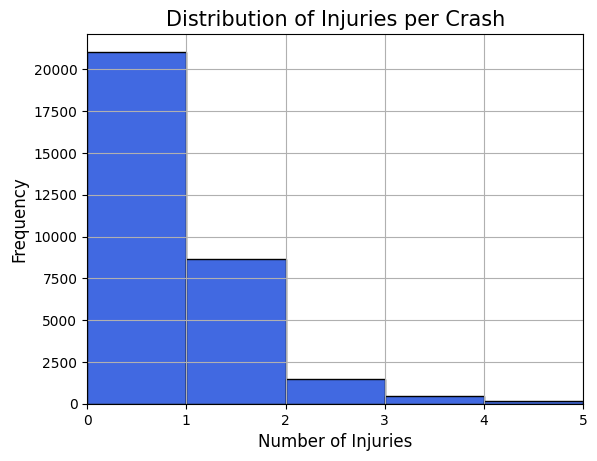

In [ ]:
#distribution of showing injuries per crash
df["number_of_persons_injured"].hist(bins=range(0, 7), color="royalblue", edgecolor="black")

plt.xlim(0,5)
plt.xticks(range(0,6))

plt.xlabel("Number of Injuries", fontsize = 12)
plt.ylabel("Frequency", fontsize = 12)
plt.title("Distribution of Injuries per Crash", fontsize = 15)

In [ ]:
#outliers
Q1 = df["number_of_persons_injured"].quantile(0.25)
Q3 = df["number_of_persons_injured"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["number_of_persons_injured"] < Q1 - 1.5 * IQR) | (df["number_of_persons_injured"] > Q3 + 1.5 * IQR)]
print("Number of outliers:", len(outliers))

Number of outliers: 712


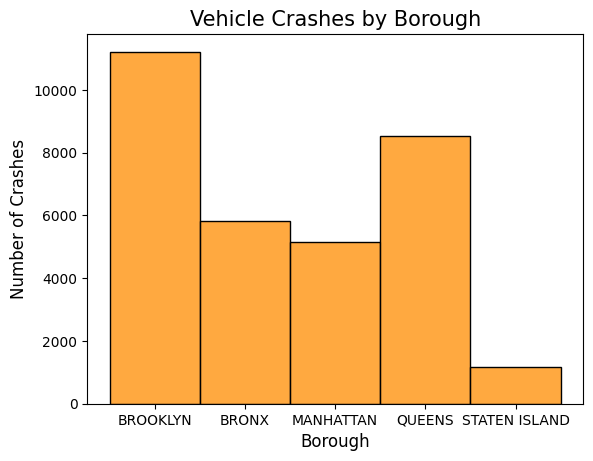

In [ ]:
# Plot of crashes by Borough
sns.histplot(df['borough'], bins = 5, color = 'darkorange', edgecolor = 'black')
plt.title('Vehicle Crashes by Borough', fontsize = 15)
plt.xlabel('Borough', fontsize = 12)
plt.ylabel('Number of Crashes', fontsize = 12)
plt.show()

In [ ]:
df["crash_hour"] = pd.to_datetime(df["crash_time"], format="%H:%M").dt.hour # extracting hour for graph

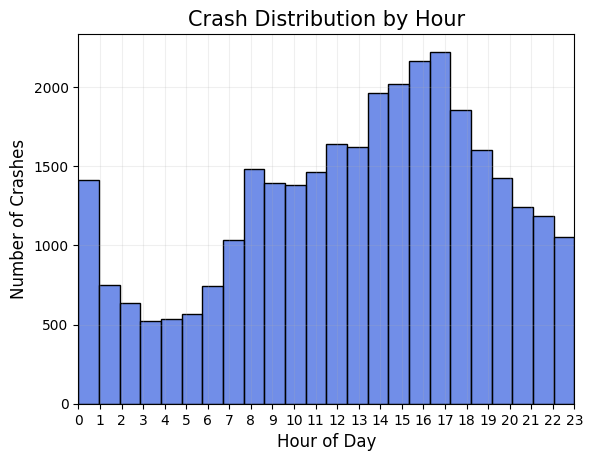

In [ ]:
sns.histplot(df['crash_hour'], bins = 24, color = 'royalblue', edgecolor = 'black')

plt.title('Crash Distribution by Hour', fontsize = 15)
plt.xlabel('Hour of Day', fontsize = 12)
plt.ylabel('Number of Crashes', fontsize = 12)
plt.xticks(range(0, 24))
plt.xlim(0, 23)
plt.grid(True, alpha = 0.2)
plt.show()

In [ ]:
top_factors = df["contributing_factor_vehicle_1"].value_counts().head(11)[1:]  # Top 10 factors not including unspecified

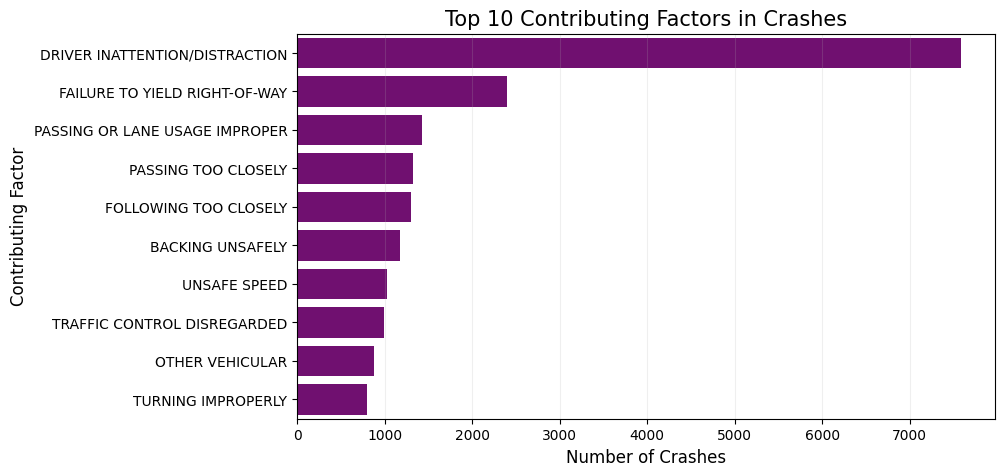

In [ ]:
plt.figure(figsize = (9,5))
sns.barplot(x = top_factors.values, y = top_factors.index, color = 'purple')
plt.title("Top 10 Contributing Factors in Crashes", fontsize=15)
plt.xlabel("Number of Crashes", fontsize=12)
plt.ylabel("Contributing Factor", fontsize=12)
plt.grid(axis="x", alpha = 0.2)
plt.show()

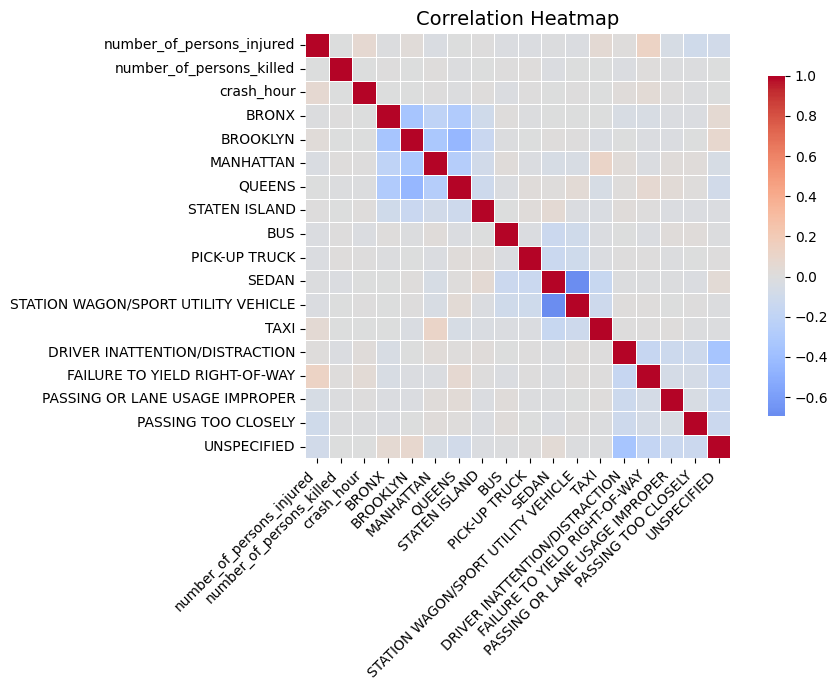

In [ ]:
#Correlation
numeric_cols = [
    'number_of_persons_injured',
    'number_of_persons_killed'
]

top_boroughs = df['borough'].value_counts().nlargest(5).index
borough_dummies = pd.get_dummies(
    df['borough'].where(df['borough'].isin(top_boroughs))
)

top_vehicles = df['vehicle_type_code1'].value_counts().nlargest(5).index
vehicle_dummies = pd.get_dummies(
    df['vehicle_type_code1'].where(df['vehicle_type_code1'].isin(top_vehicles))
)

top_factors = df['contributing_factor_vehicle_1'].value_counts().nlargest(5).index
factor_dummies = pd.get_dummies(
    df['contributing_factor_vehicle_1'].where(df['contributing_factor_vehicle_1'].isin(top_factors))
)

df_corr = pd.concat([df[numeric_cols],df[['crash_hour']],borough_dummies,vehicle_dummies,factor_dummies],axis=1)

corr = df_corr.corr()

plt.figure(figsize=(10,7))

sns.heatmap(corr, cmap= 'coolwarm',center=0,linewidths=0.5,square=True,cbar_kws={"shrink":0.8})

plt.title('Correlation Heatmap', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
#mapping using longitudes and latitudes
url = "https://data.cityofnewyork.us/resource/h9gi-nx95.json"
params = {"$limit": 50000}
resp_map = requests.get(url, params=params)
df_map = pd.DataFrame(resp_map.json())

df_map.columns = df_map.columns.str.lower().str.strip().str.replace(" ", "_")

if "location" in df_map.columns:
    df_map = df_map.drop(columns=["location"])

df_map = df_map.dropna(subset=['latitude', 'longitude']).copy()

df_map['latitude'] = pd.to_numeric(df_map['latitude'])
df_map['longitude'] = pd.to_numeric(df_map['longitude'])

print(f"Rows: {len(df_map)}")


Rows: 46090


In [ ]:
import folium as fol

mean_lat = df_map['latitude'].mean()
mean_lon = df_map['longitude'].mean()
m_temp = fol.Map(location=[mean_lat, mean_lon], zoom_start=9)

for index,row in df_map.sample(1000).iterrows():
    fol.Marker(
        location=[row['latitude'], row['longitude']],
        tooltip=f"Collision ID: {row['collision_id']}"
    ).add_to(m_temp)

m_temp

In [ ]:
#export as sqlite DB
import sqlite3

# Step 1: Export
conn = sqlite3.connect("nyc_crashes.db")
df.to_sql("collisions", conn, if_exists="replace", index=False)

# Step 2: Verify immediately using same connection
result = pd.read_sql("SELECT * FROM collisions LIMIT 5", conn)
conn.close()

print("✅ Export successful!")
print(f"Rows exported: {len(df)}")
result


✅ Export successful!
Rows exported: 31905


,crash_date,crash_time,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,number_of_motorist_injured,number_of_motorist_killed,contributing_factor_vehicle_1,contributing_factor_vehicle_2,collision_id,vehicle_type_code1,vehicle_type_code2,borough,zip_code,crash_hour
0,2023-11-01 00:00:00,1:29,1,0,0,0,0,0,1,0,UNSPECIFIED,UNSPECIFIED,4675373,MOPED,SEDAN,BROOKLYN,11230,1
1,2021-09-11 00:00:00,9:35,0,0,0,0,0,0,0,0,UNSPECIFIED,None,4456314,SEDAN,None,BROOKLYN,11208,9
2,2021-12-14 00:00:00,8:13,0,0,0,0,0,0,0,0,None,None,4486609,None,None,BROOKLYN,11233,8
3,2021-12-14 00:00:00,8:17,2,0,0,0,0,0,2,0,UNSPECIFIED,UNSPECIFIED,4486660,SEDAN,SEDAN,BRONX,10475,8
4,2021-12-14 00:00:00,21:10,0,0,0,0,0,0,0,0,DRIVER INEXPERIENCE,UNSPECIFIED,4487074,SEDAN,None,BROOKLYN,11207,21


In [ ]:
from google.colab import files
files.download("nyc_crashes.db")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>